# Financial Transaction Fraud Detection — EDA & Data Preparation

**Dataset:** PaySim (synthetic mobile-money transactions)
**Target:** `isFraud` (1 = fraud)

This notebook covers: business understanding, data exploration, quality checks, EDA, and feature engineering setup.

## 1. Setup & Load

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("../data/raw/fraud_0.1origbase.csv")
df.shape

(636262, 11)

In [2]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,283,CASH_IN,210329.84,C1159819632,3778062.79,3988392.64,C1218876138,1519266.60,1308936.76,0,0
1,132,CASH_OUT,215489.19,C1372369468,21518.00,0.00,C467105520,6345756.55,6794954.89,0,0
2,355,DEBIT,4431.05,C1059822709,20674.00,16242.95,C76588246,80876.56,85307.61,0,0
3,135,CASH_OUT,214026.20,C1464960643,46909.73,0.00,C1059379810,13467450.36,13681476.56,0,0
4,381,CASH_OUT,8858.45,C831134427,0.00,0.00,C579876929,1667180.58,1676039.03,0,0


## 2. Business Understanding

Fraud is **rare but costly**. We must catch fraud (high recall) without flooding analysts with false alarms (reasonable precision). Accuracy is a *trap* here — see below.

In [3]:
fraud_rate = df['isFraud'].mean()
print(f"Fraud cases : {df['isFraud'].sum():,}")
print(f"Total       : {len(df):,}")
print(f"Fraud rate  : {fraud_rate*100:.4f}%")
print(f"\nA 'predict never-fraud' model would score {(1-fraud_rate)*100:.2f}% accuracy — and catch ZERO fraud.")

Fraud cases : 821
Total       : 636,262
Fraud rate  : 0.1290%

A 'predict never-fraud' model would score 99.87% accuracy — and catch ZERO fraud.


## 3. Data Quality Checks
Missing values, duplicates, data types.

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)

Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0

Data types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


## 4. Key Finding — Fraud Only Occurs in CASH_OUT & TRANSFER

This is the single most important insight. It justifies filtering the data to these two types.

In [5]:
by_type = df.groupby('type')['isFraud'].agg(count='count', fraud='sum', rate='mean')
by_type['rate_%'] = (by_type['rate']*100).round(4)
by_type

,count,fraud,rate,rate_%
type,,,,
CASH_IN,139614,0,0.000000,0.0000
CASH_OUT,224216,407,0.001815,0.1815
DEBIT,4170,0,0.000000,0.0000
PAYMENT,214968,0,0.000000,0.0000
TRANSFER,53294,414,0.007768,0.7768


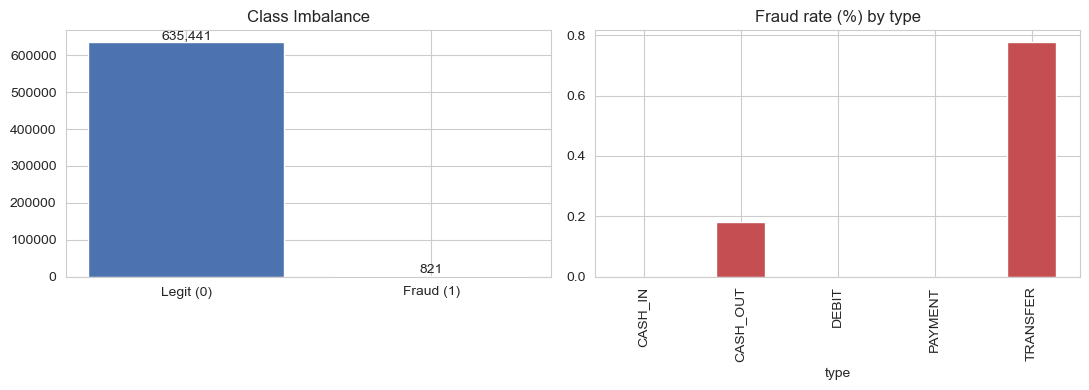

In [6]:
fig, ax = plt.subplots(1,2, figsize=(11,4))
vc = df['isFraud'].value_counts()
ax[0].bar(['Legit (0)','Fraud (1)'], vc.values, color=['#4C72B0','#C44E52'])
ax[0].set_title('Class Imbalance'); 
for i,v in enumerate(vc.values): ax[0].text(i, v, f"{v:,}", ha='center', va='bottom')
(df.groupby('type')['isFraud'].mean()*100).plot(kind='bar', ax=ax[1], color='#C44E52')
ax[1].set_title('Fraud rate (%) by type'); plt.tight_layout(); plt.show()

## 5. Filter to Fraud-Capable Types
Drop CASH_IN, PAYMENT, DEBIT (0% fraud). Effective fraud rate roughly doubles.

In [7]:
d = df[df['type'].isin(['CASH_OUT','TRANSFER'])].copy()
print("Rows after filter:", len(d))
print(f"New fraud rate   : {d['isFraud'].mean()*100:.4f}%")

Rows after filter: 277510
New fraud rate   : 0.2958%


## 6. Feature Engineering — Balance Error Terms

Balance arithmetic should reconcile: `oldbalance - amount - newbalance == 0`.
We compute the residual for both sides of the transaction, plus a full-drain flag.

**Read the output below carefully — the result is the opposite of the intuition.**

In [8]:
d['errorBalanceOrig'] = d['oldbalanceOrg'] - d['amount'] - d['newbalanceOrig']
d['errorBalanceDest'] = d['oldbalanceDest'] + d['amount'] - d['newbalanceDest']

# Full-drain flag: fraud almost always empties the sender's account
d['isFullDrain'] = np.isclose(d['amount'], d['oldbalanceOrg']).astype(int)

d.groupby('isFraud')[['amount','errorBalanceOrig','errorBalanceDest','isFullDrain']].median()

,amount,errorBalanceOrig,errorBalanceDest,isFullDrain
isFraud,,,,
0,170997.65,-143876.77,0.0,0.0
1,404394.04,0.00,4232.0,1.0


### Correcting the interpretation — fraud reconciles, legitimate traffic does not

The median errorBalanceOrig is 0.00 for fraudulent transactions and large and negative for legitimate transactions. This indicates that fraudulent transactions generally satisfy the balance identity, whereas many legitimate transactions do not. This pattern is a characteristic of the PaySim simulator, where legitimate CASH_OUT transactions do not always update newbalanceOrig consistently. Consequently, reconciliation-based features remain highly predictive, but their predictive power reflects a simulator artifact rather than an inherent property of real-world fraud.

In [9]:
f, l = d[d.isFraud==1], d[d.isFraud==0]

print("Share of rows where errorBalanceOrig == 0 (reconciles exactly)")
print(f"  Fraud       : {np.isclose(f.errorBalanceOrig, 0).mean()*100:.2f}%")
print(f"  Legitimate  : {np.isclose(l.errorBalanceOrig, 0).mean()*100:.2f}%")

print("\nWhy legitimate rows fail to reconcile:")
print(f"  Legit rows with oldbalanceOrg == 0 : {(l.oldbalanceOrg==0).mean()*100:.2f}%")
print(f"  Legit rows where error == -amount  : {np.isclose(l.errorBalanceOrig, -l.amount).mean()*100:.2f}%")

Share of rows where errorBalanceOrig == 0 (reconciles exactly)
  Fraud       : 99.51%
  Legitimate  : 9.26%

Why legitimate rows fail to reconcile:
  Legit rows with oldbalanceOrg == 0 : 47.28%
  Legit rows where error == -amount  : 47.29%


**Interpretation.**

- **Fraud reconciles.** 99.51% of fraudulent rows have `errorBalanceOrig` exactly 0, because the
  PaySim fraud agent transfers the entire balance and correctly writes `newbalanceOrig = 0`.
- **Legitimate traffic does not.** Only 9.26% of legitimate rows reconcile. The cause is a data
  artifact: 47.3% of legitimate rows carry unpopulated balance fields
  (`oldbalanceOrg = newbalanceOrig = 0`), which forces `errorBalanceOrig = -amount` and drags the
  legitimate median to roughly -143,877.

The feature is still valid and highly predictive, but it separates the classes by detecting a
**property of the data generator**, not by detecting broken accounting. This is the clearest single
piece of evidence supporting the limitations discussed in Section 10 of `02_modeling`.

### The strongest single signal: account drain

In [10]:
drain = d.groupby('isFraud')['isFullDrain'].mean()*100
print(drain)
# ~98% of fraud drains the account vs ~0% of legit transactions

isFraud
0     0.000000
1    97.929354
Name: isFullDrain, dtype: float64


## 7. Amount Distribution
Fraud skews to larger amounts.

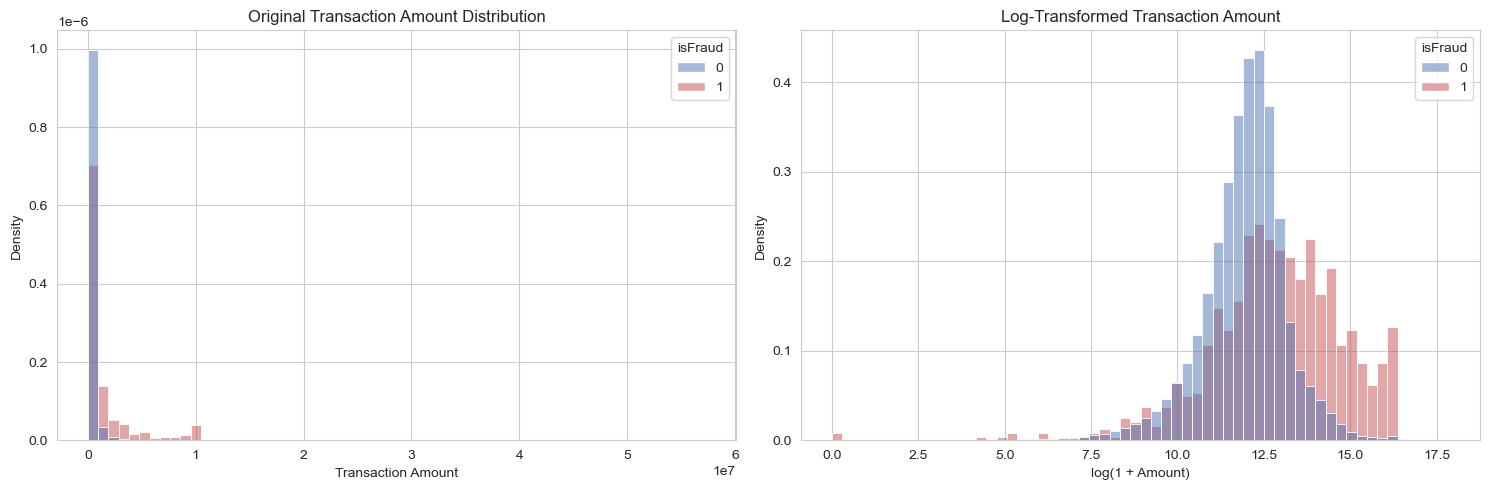

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Original Distribution
sns.histplot(
    data=d,
    x="amount",
    hue="isFraud",
    bins=60,
    stat="density",
    common_norm=False,
    palette=["#4C72B0", "#C44E52"],
    ax=axes[0]
)

axes[0].set_title("Original Transaction Amount Distribution")
axes[0].set_xlabel("Transaction Amount")
axes[0].set_ylabel("Density")

# Log-transformed Distribution
sns.histplot(
    x=np.log1p(d["amount"]),
    hue=d["isFraud"],
    bins=60,
    stat="density",
    common_norm=False,
    palette=["#4C72B0", "#C44E52"],
    ax=axes[1]
)

axes[1].set_title("Log-Transformed Transaction Amount")
axes[1].set_xlabel("log(1 + Amount)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

### Interpretation

The original transaction amount distribution is positively (right) skewed, indicating that the majority of financial transactions involve relatively small monetary amounts, while only a limited number of transactions involve very large values.

This behaviour is expected in real-world financial systems because routine customer transactions generally consist of low or medium amounts, whereas high-value transfers occur less frequently.

To improve visualization, a logarithmic transformation (`log1p`) was applied. The transformation compresses extreme values while preserving the relative ordering of transactions, making it easier to compare the distributions of legitimate and fraudulent transactions.

The analysis suggests that fraudulent transactions tend to occur more frequently among higher-value transactions; however, transaction amount alone is insufficient for fraud classification and should be considered together with balance-related features.

## 8. Correlation Heatmap

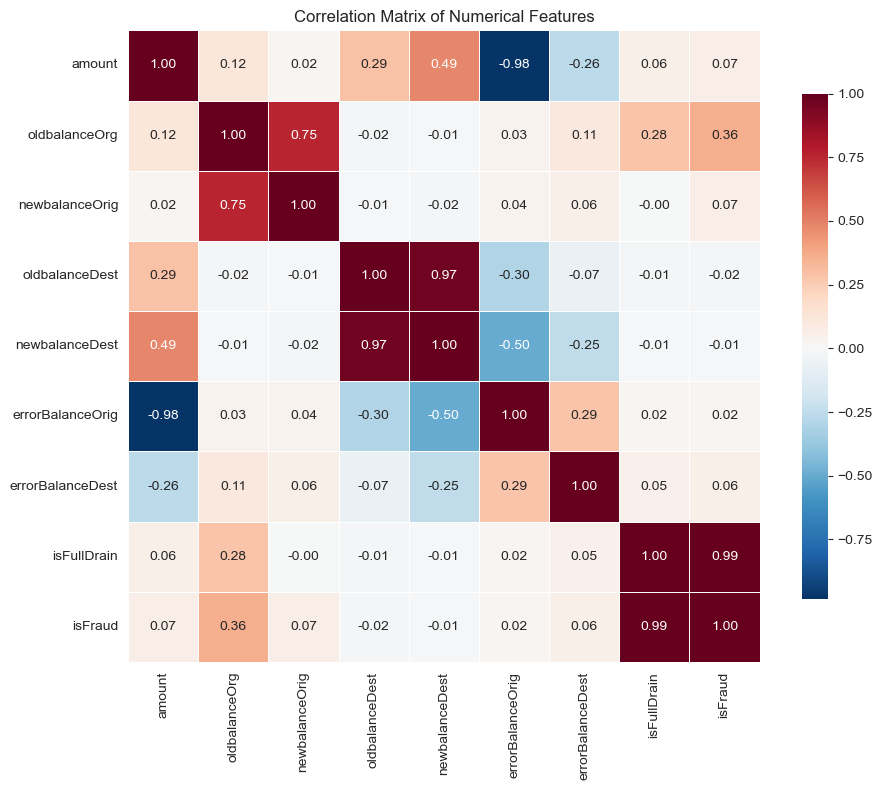

In [12]:
num = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'errorBalanceOrig',
    'errorBalanceDest',
    'isFullDrain',
    'isFraud'
]

corr = d[num].corr(method='pearson')

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Observation

The correlation matrix illustrates both positive and negative linear relationships among the numerical variables.

Negative correlation values indicate that as one variable increases, the other tends to decrease. This behaviour is expected for financial balance variables because money transferred from one account reduces the sender's balance while increasing the receiver's balance.

Several observations can be made:

- `oldbalanceOrg` and `newbalanceOrig` exhibit a strong positive correlation because account balances before and after a transaction are naturally related.
- `errorBalanceOrig` and `isFullDrain` demonstrate meaningful relationships with fraudulent transactions.
- Most individual variables show relatively weak direct correlation with the target variable (`isFraud`), suggesting that fraud detection depends on combinations of features rather than a single predictor.
- The presence of negative correlations does not indicate a problem with the dataset; instead, it reflects the underlying financial transaction dynamics.

## 9. Save Processed Data

We drop `nameOrig` / `nameDest` (high-cardinality identifiers with no predictive content) and
`isFlaggedFraud`.

**`isFlaggedFraud` is dropped as leakage, not as a useless flag.** It is the output of the
simulator's own rule engine — a downstream decision made by the fraud system itself, not an
attribute of the transaction observable at scoring time. Including it would leak a partial label
into the feature set. It is separately negligible (2 positives in 636,262 rows, both fraud), but
the leakage argument is the binding one: even a perfectly informative post-hoc system flag would
have to be excluded.

In [13]:
import os
os.makedirs("../data/processed", exist_ok=True)

d = d.drop(columns=['nameOrig','nameDest','isFlaggedFraud'])
d.to_csv("../data/processed/fraud_processed.csv", index=False)
print("Saved:", d.shape)
d.head()

Saved: (277510, 11)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,isFullDrain
1,132,CASH_OUT,215489.19,21518.00,0.0,6345756.55,6794954.89,0,-193971.19,-2.337091e+05,0
3,135,CASH_OUT,214026.20,46909.73,0.0,13467450.36,13681476.56,0,-167116.47,-1.862645e-09,0
4,381,CASH_OUT,8858.45,0.00,0.0,1667180.58,1676039.03,0,-8858.45,0.000000e+00,0
6,347,CASH_OUT,120989.98,0.00,0.0,6963396.37,7084386.35,0,-120989.98,9.313226e-10,0
7,183,CASH_OUT,62655.01,18997.00,0.0,130706.17,193361.18,0,-43658.01,0.000000e+00,0


# Exploratory Data Analysis Summary

The exploratory data analysis produced several important insights that guided the subsequent machine learning workflow.

## Key Findings

- The dataset contains no missing values or duplicate records, indicating good data quality.
- Fraudulent transactions represent only a very small proportion of all observations, confirming a highly imbalanced classification problem.
- Fraud occurs exclusively within the `TRANSFER` and `CASH_OUT` transaction categories in the filtered dataset.
- Transaction amounts exhibit a positively skewed distribution, which is consistent with real-world financial transaction behaviour.
- Engineered features, particularly `errorBalanceOrig`, `errorBalanceDest`, and `isFullDrain`, capture meaningful transaction inconsistencies associated with fraudulent activity.
- Correlation analysis indicates that no single feature strongly predicts fraud, highlighting the importance of combining multiple variables through machine learning models.
- Extreme values observed in financial variables are considered genuine characteristics of financial transactions and were therefore retained for model training.

These findings informed the preprocessing strategy and feature engineering process adopted during the modelling phase.